c:\Users\try\OneDrive\Desktop\CustomerExperienceAnalytics_Fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully loaded data from: ..\data\cleaned_reviews.csv
DataFrame head:
                                               review  rating        date bank  \
0  A great app. It's like carrying a bank in your...       4  2025-06-07  CBE   
1                      More than garrantty bank EBC.       4  2025-06-07  CBE   
2  really am happy to this app it is Siple to use...       5  2025-06-07  CBE   
3  I liked this app. But the User interface is ve...       2  2025-06-07  CBE   
4  "Why don’t your ATMs support account-to-accoun...       4  2025-06-06  CBE   

        source  
0  Google Play  
1  Google Play  
2  Google Play  
3  Google Play  
4  Google Play  
DataFrame columns:
 Index(['review', 'rating', 'date', 'bank', 'source'], dtype='object')
Starting sentiment analysis...


Device set to use cpu


Sentiment analysis complete.

DataFrame with Sentiment Analysis Results:
                                              review  rating        date bank  \
0  A great app. It's like carrying a bank in your...       4  2025-06-07  CBE   
1                      More than garrantty bank EBC.       4  2025-06-07  CBE   
2  really am happy to this app it is Siple to use...       5  2025-06-07  CBE   
3  I liked this app. But the User interface is ve...       2  2025-06-07  CBE   
4  "Why don’t your ATMs support account-to-accoun...       4  2025-06-06  CBE   

        source sentiment_label  sentiment_score  
0  Google Play        POSITIVE         0.999293  
1  Google Play        POSITIVE         0.997196  
2  Google Play        POSITIVE         0.998870  
3  Google Play        NEGATIVE         0.999684  
4  Google Play        NEGATIVE         0.996465  


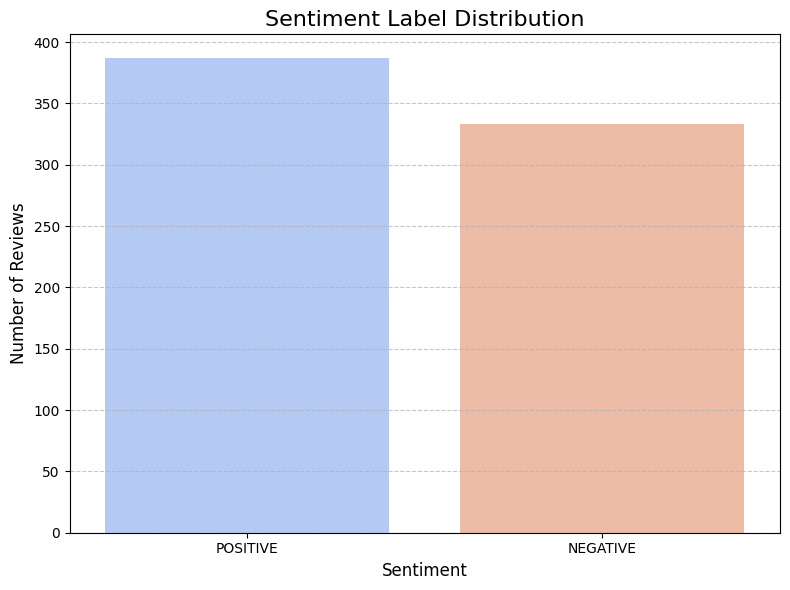

C:\Users\try\AppData\Local\Temp\ipykernel_23132\2481738472.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sentiment_label", y="sentiment_score", palette="coolwarm")


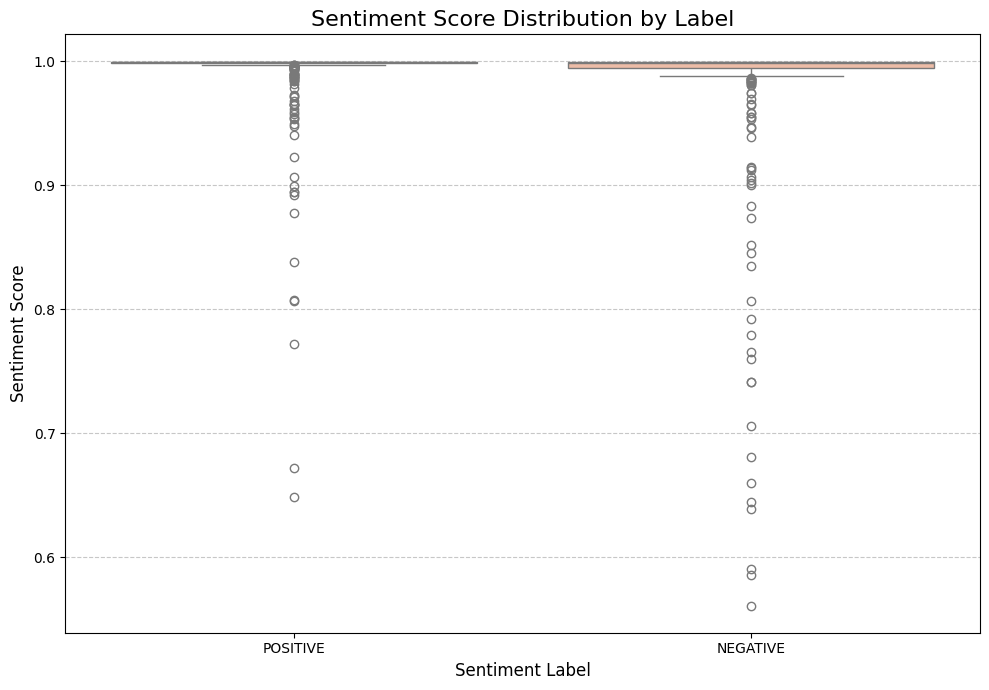


Negative Sentiment Reviews (first 10 rows):
                                                review  sentiment_score
3   I liked this app. But the User interface is ve...         0.999684
4   "Why don’t your ATMs support account-to-accoun...         0.996465
5                         what is this app problem???         0.999623
7     I cannot send to cbebirr app. through this app.         0.995335
8                                      not functional         0.999779
9   everytime you uninstall the app you have to re...         0.990516
10  it was good app but it have some issues like i...         0.998119
12                                   it is not safety         0.999787
13  it is like a childish app make it better the w...         0.999796
16  this app has developed in a very good ways but...         0.998314

Positive Sentiment Reviews (first 10 rows):
                                                review  sentiment_score
0   A great app. It's like carrying a bank in your...   

In [1]:
# ## Exploratory Sentiment Analysis with DistilBERT

# Import libraries
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import os module for path manipulation

# --- Code changes start here ---

# Determine the path to the 'data' directory relative to the current notebook
# Assuming the notebook is in 'notebooks/' and data is in 'data/'
# So, navigate one level up (..) and then into 'data'
data_input_file_path = os.path.join('..', 'data', 'cleaned_reviews.csv')
data_output_file_path = os.path.join('..', 'data', 'cleaned_reviews_with_sentiment.csv') # New output file

# Load your dataset from the specified path
# Make sure your CSV file has a column named 'review' containing text data
try:
    df = pd.read_csv(data_input_file_path)
    print(f"Successfully loaded data from: {data_input_file_path}")
    # Display the first few rows and columns to verify data loading
    print("DataFrame head:\n", df.head())
    print("DataFrame columns:\n", df.columns)

    # IMPORTANT: If your text column is named something other than 'review',
    # you will need to rename it or adjust the 'df["review"]' references below.
    # Example if your column is named 'text_content':
    # df.rename(columns={'text_content': 'review'}, inplace=True)

except FileNotFoundError:
    print(f"Error: The file '{data_input_file_path}' was not found. Please ensure the path is correct and the file exists.")
    print("Current working directory:", os.getcwd())
    # Exit or handle the error gracefully if the file isn't found
    exit()
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")
    exit()

# Ensure the 'review' column exists before proceeding
if 'review' not in df.columns:
    print("Error: The DataFrame does not contain a 'review' column. Please check your CSV file or rename the appropriate column.")
    exit()

# Remove rows where the 'review' column might be empty or NaN, as the model needs text input
df.dropna(subset=['review'], inplace=True)
if df.empty:
    print("Error: No valid reviews found after cleaning. Cannot perform sentiment analysis.")
    exit()

# --- End of code changes ---


# Define the sentiment computation function using DistilBERT
def compute_bert_sentiment(df):
    print("Starting sentiment analysis...")
    # Initialize the sentiment analysis pipeline with the pre-trained DistilBERT model
    # "distilbert-base-uncased-finetuned-sst-2-english" is suitable for general sentiment.
    classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
    
    # Process reviews in batches if the dataset is large to avoid memory issues
    # The `truncation=True` parameter handles reviews longer than the model's max input length
    sentiments = classifier(df["review"].tolist(), truncation=True)
    
    # Extract the sentiment label (e.g., POSITIVE, NEGATIVE) and score for each review
    df["sentiment_label"] = [s['label'] for s in sentiments]
    df["sentiment_score"] = [s['score'] for s in sentiments]
    print("Sentiment analysis complete.")
    return df

# Apply sentiment analysis
df = compute_bert_sentiment(df)

# Display the dataframe with sentiments
print("\nDataFrame with Sentiment Analysis Results:")
print(df.head()) # Displaying head as the full dataframe might be too large

# Basic EDA: Count of sentiment labels
plt.figure(figsize=(8, 6)) # Increased figure size for better readability
sns.countplot(data=df, x="sentiment_label", palette="coolwarm", hue="sentiment_label", legend=False) # Added hue and removed legend for clearer color mapping
plt.title("Sentiment Label Distribution", fontsize=16) # Larger title
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for better visualization
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Distribution of sentiment scores by label
plt.figure(figsize=(10, 7)) # Increased figure size
sns.boxplot(data=df, x="sentiment_label", y="sentiment_score", palette="coolwarm")
plt.title("Sentiment Score Distribution by Label", fontsize=16)
plt.xlabel("Sentiment Label", fontsize=12)
plt.ylabel("Sentiment Score", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Show reviews with negative sentiment for deeper insight
print("\nNegative Sentiment Reviews (first 10 rows):\n", df[df['sentiment_label'] == 'NEGATIVE'][['review', 'sentiment_score']].head(10))

# Show reviews with positive sentiment for deeper insight
print("\nPositive Sentiment Reviews (first 10 rows):\n", df[df['sentiment_label'] == 'POSITIVE'][['review', 'sentiment_score']].head(10))

# --- Added code to save the results ---
df.to_csv(data_output_file_path, index=False)
print(f"\nSentiment analysis results saved to '{data_output_file_path}'")
